In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [62]:
import os

print(os.getcwd())

c:\Users\diyathakur\Desktop\Diabetes-Prediction\notebooks


In [63]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv("../data/diabetes.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (768, 9)


In [64]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [65]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [66]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [67]:
print("Diabetes outcome distribution:")
print(df["Outcome"].value_counts())

print("\nPercentage distribution:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Diabetes outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [68]:
# Create a copy so the original dataset remains unchanged
data = df.copy()

print("Copy created successfully!")

Copy created successfully!


In [69]:
# Columns where zero values are treated as missing
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values before preprocessing:")

for column in zero_columns:
    print(column, ":", (data[column] == 0).sum())

Zero values before preprocessing:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [70]:
import numpy as np

# Replace invalid zero values with NaN
data[zero_columns] = data[zero_columns].replace(0, np.nan)

print("Invalid zero values replaced with NaN.")

Invalid zero values replaced with NaN.


In [71]:
print("Missing values after replacing zeros:")
print(data.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [72]:
# Fill missing values using the median of each column
for column in zero_columns:
    data[column] = data[column].fillna(data[column].median())

print("Missing values filled using median imputation.")

Missing values filled using median imputation.


In [73]:
print("Missing values after preprocessing:")
print(data.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [74]:
# Separate input features and target variable

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [77]:
# Separate input features and target variable

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [79]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [80]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [81]:
# Make predictions on the test data
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [1 0 0 0 0 0 1 1 0 1]


In [82]:
print("Number of test samples:", len(y_test))
print("Number of predictions:", len(y_pred))

Number of test samples: 154
Number of predictions: 154


In [83]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")

Random Forest Accuracy: 77.92 %


In [84]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1-Score  :", round(f1 * 100, 2), "%")

Random Forest Performance
-------------------------
Accuracy  : 77.92 %
Precision : 72.73 %
Recall    : 59.26 %
F1-Score  : 65.31 %


In [85]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[88 12]
 [22 32]]


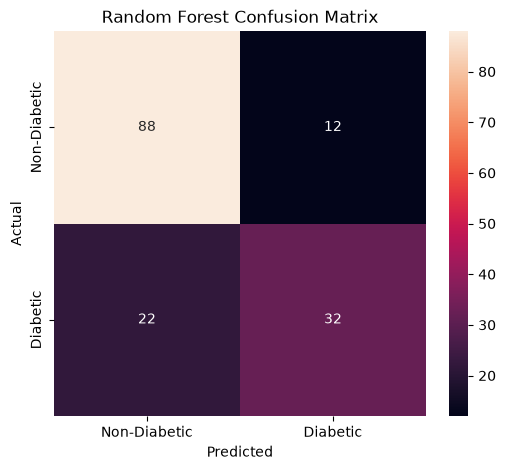

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [87]:
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [88]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [89]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)

# Naive Bayes metrics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

# Decision Tree metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("MODEL PERFORMANCE")
print("=================")

print("\nRandom Forest")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1-Score :", round(rf_f1 * 100, 2), "%")

print("\nNaive Bayes")
print("Accuracy :", round(nb_accuracy * 100, 2), "%")
print("Precision:", round(nb_precision * 100, 2), "%")
print("Recall   :", round(nb_recall * 100, 2), "%")
print("F1-Score :", round(nb_f1 * 100, 2), "%")

print("\nDecision Tree")
print("Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Precision:", round(dt_precision * 100, 2), "%")
print("Recall   :", round(dt_recall * 100, 2), "%")
print("F1-Score :", round(dt_f1 * 100, 2), "%")

MODEL PERFORMANCE

Random Forest
Accuracy : 77.92 %
Precision: 72.73 %
Recall   : 59.26 %
F1-Score : 65.31 %

Naive Bayes
Accuracy : 70.13 %
Precision: 56.67 %
Recall   : 62.96 %
F1-Score : 59.65 %

Decision Tree
Accuracy : 68.18 %
Precision: 55.32 %
Recall   : 48.15 %
F1-Score : 51.49 %


In [91]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Naive Bayes",
        "Decision Tree"
    ],
    "Accuracy": [
        rf_accuracy,
        nb_accuracy,
        dt_accuracy
    ],
    "Precision": [
        rf_precision,
        nb_precision,
        dt_precision
    ],
    "Recall": [
        rf_recall,
        nb_recall,
        dt_recall
    ],
    "F1-Score": [
        rf_f1,
        nb_f1,
        dt_f1
    ]
})

# Convert values to percentages
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results[column] = results[column] * 100

results.round(2)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,77.92,72.73,59.26,65.31
1,Naive Bayes,70.13,56.67,62.96,59.65
2,Decision Tree,68.18,55.32,48.15,51.49


In [92]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Naive Bayes",
        "Decision Tree"
    ],
    "Accuracy": [
        rf_accuracy,
        nb_accuracy,
        dt_accuracy
    ],
    "Precision": [
        rf_precision,
        nb_precision,
        dt_precision
    ],
    "Recall": [
        rf_recall,
        nb_recall,
        dt_recall
    ],
    "F1-Score": [
        rf_f1,
        nb_f1,
        dt_f1
    ]
})

# Convert values to percentages
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results[column] = results[column] * 100

results.round(2)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,77.92,72.73,59.26,65.31
1,Naive Bayes,70.13,56.67,62.96,59.65
2,Decision Tree,68.18,55.32,48.15,51.49


In [93]:
best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = results["Accuracy"].max()

print("Best Model:", best_model)
print("Best Accuracy:", round(best_accuracy, 2), "%")

Best Model: Random Forest
Best Accuracy: 77.92 %


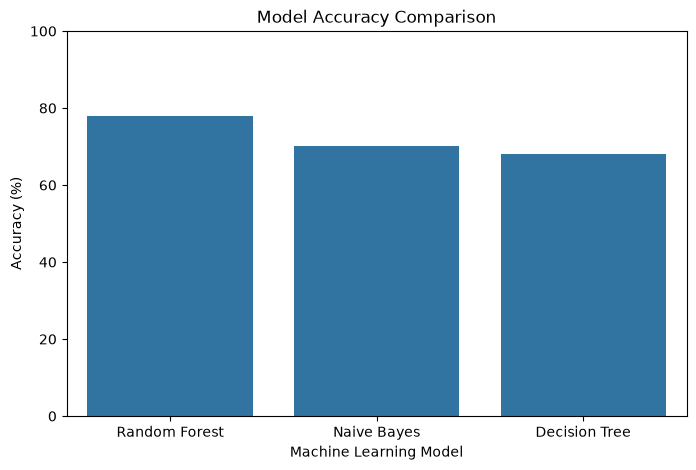

In [94]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 100)

plt.show()

In [95]:
# Save model comparison results

results.to_csv("../results/model_comparison.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [96]:
import joblib

# Select the trained model based on accuracy
model_dictionary = {
    "Random Forest": rf_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model
}

best_trained_model = model_dictionary[best_model]

# Save the best model
joblib.dump(
    best_trained_model,
    "../models/best_diabetes_model.pkl"
)

print("Best model:", best_model)
print("Model saved successfully!")

Best model: Random Forest
Model saved successfully!


In [97]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [98]:
# Test loading the saved model

loaded_model = joblib.load(
    "../models/best_diabetes_model.pkl"
)

print("Saved model loaded successfully!")
print("Model type:", type(loaded_model).__name__)

Saved model loaded successfully!
Model type: RandomForestClassifier


In [99]:
# Test the loaded model

if best_model == "Naive Bayes":
    test_predictions = loaded_model.predict(X_test_scaled)
else:
    test_predictions = loaded_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

print("Loaded model accuracy:",
      round(test_accuracy * 100, 2), "%")

Loaded model accuracy: 77.92 %


In [100]:
# Save the median values used for preprocessing

median_values = {}

for column in zero_columns:
    median_values[column] = data[column].median()

joblib.dump(
    median_values,
    "../models/median_values.pkl"
)

print("Preprocessing median values saved successfully!")

Preprocessing median values saved successfully!


In [101]:
# Final model comparison table

final_results = results.copy()

print("FINAL MODEL COMPARISON")
display(final_results.round(2))

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,77.92,72.73,59.26,65.31
1,Naive Bayes,70.13,56.67,62.96,59.65
2,Decision Tree,68.18,55.32,48.15,51.49


In [102]:
# Save final comparison table

final_results.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Final comparison table saved successfully!")

Final comparison table saved successfully!


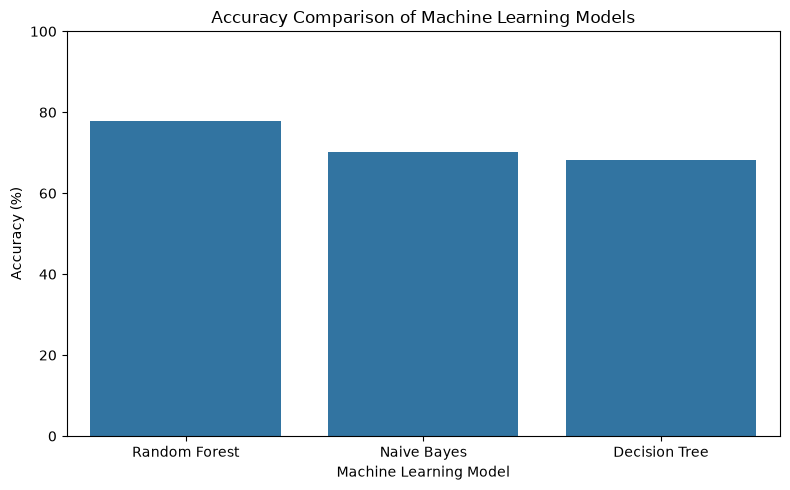

In [103]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()

plt.savefig(
    "../results/model_accuracy_comparison.png",
    dpi=300
)

plt.show()

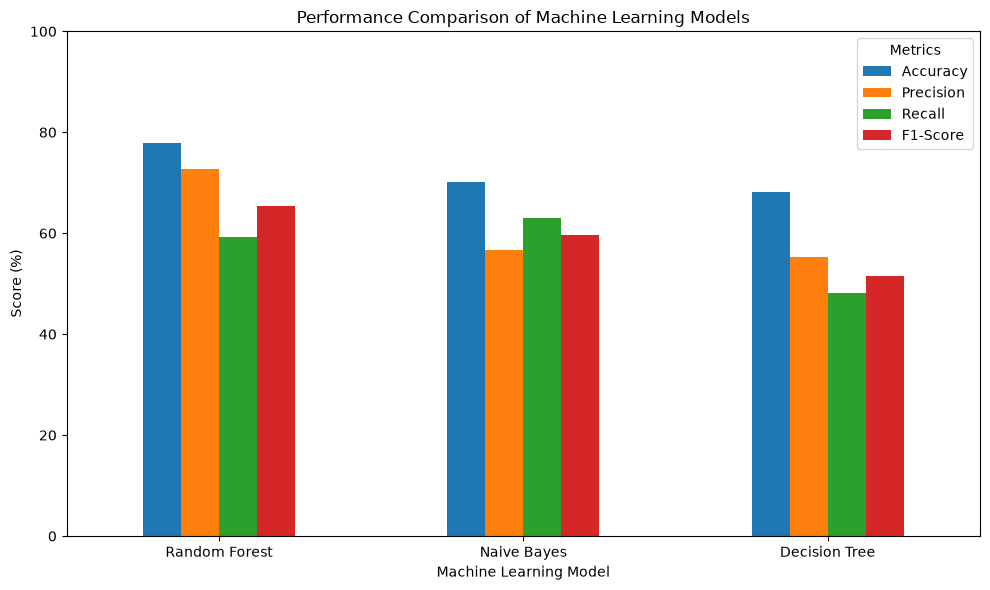

In [104]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

plot_data = final_results.set_index("Model")[metrics]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.tight_layout()

plt.savefig(
    "../results/all_metrics_comparison.png",
    dpi=300
)

plt.show()

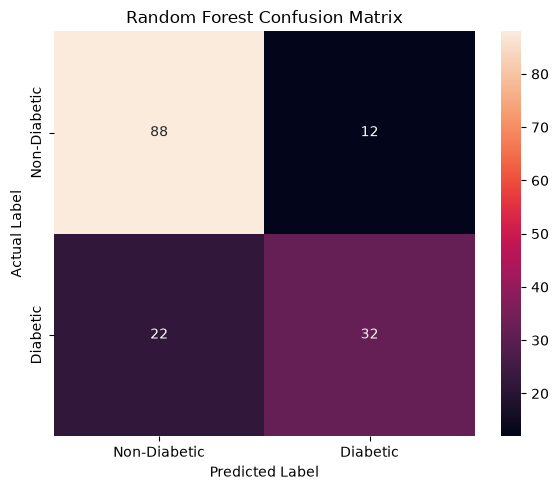

In [105]:
# Final Random Forest confusion matrix

rf_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "../results/random_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

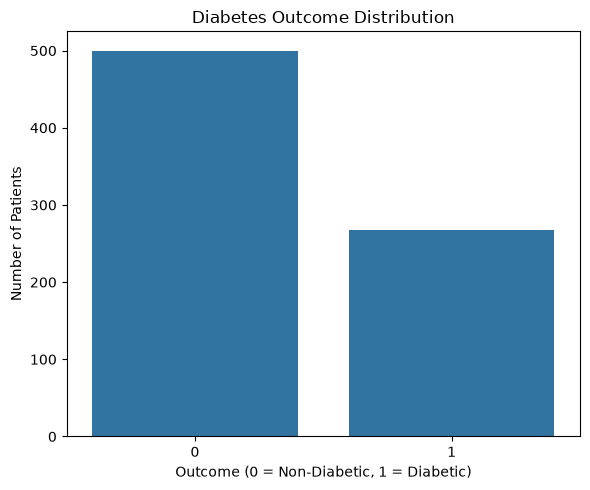

In [106]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=data,
    x="Outcome"
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/diabetes_distribution.png",
    dpi=300
)

plt.show()

In [108]:
import joblib

loaded_model = joblib.load("../models/best_diabetes_model.pkl")

print("Saved model:", type(loaded_model).__name__)

Saved model: RandomForestClassifier
